In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.spatial.distance import euclidean, cityblock
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer

#### Loading the data

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target

In [5]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### Basic EDA

In [4]:
# column datatypes
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [6]:
# missing values
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [7]:
# summary statistics 
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
# class distribution
df.target.value_counts()

target
1    357
0    212
Name: count, dtype: int64

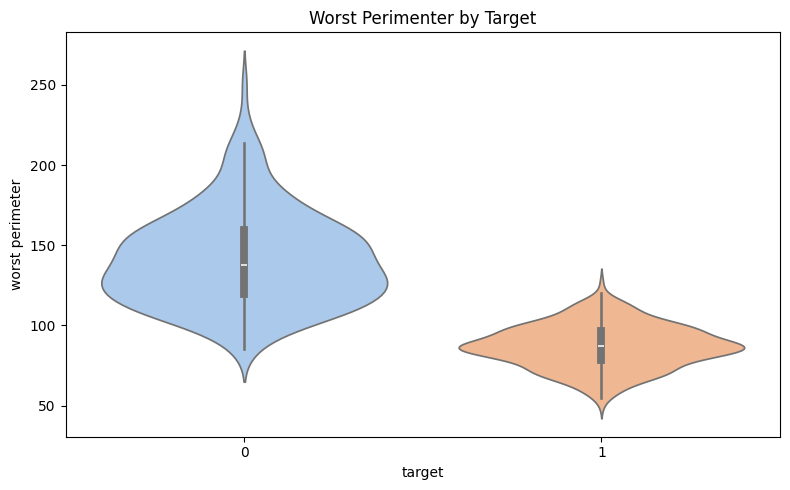

In [11]:
# Violin plot of worst perimeter by target
plt.figure(figsize=(8, 5))
sns.violinplot(x="target", y="worst perimeter", data=df, palette="pastel", hue="target", legend=False)
plt.title("Worst Perimenter by Target")
plt.tight_layout()
plt.show()

In [12]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [13]:
# distance metrics demonstration
a = X_train[0]
b = X_train[1]

print(f"Euclidean distance: {round(euclidean(a, b), 2)}")
print(f"Manhattan distance: {round(cityblock(a, b),2)}")

Euclidean distance: 94.22
Manhattan distance: 165.63


In [15]:
# Data standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=data.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.709821,-0.258417,-0.637396,-0.711996,1.628430,0.847289,0.166501,0.196420,0.542716,1.347151,...,-0.600068,-0.065867,-0.565662,-0.622613,2.019222,0.186202,0.180187,0.400933,-0.414074,0.445223
1,-0.830331,2.231127,-0.874980,-0.779081,-1.597569,-1.267717,-1.086471,-1.243232,-2.658543,-1.052699,...,-0.897361,1.975153,-0.949574,-0.779331,-1.747652,-1.229372,-1.258947,-1.692788,-2.095723,-1.323417
2,-1.011097,-0.227270,-1.035172,-0.911780,-1.077779,-1.098096,-0.841650,-0.955767,2.023790,-0.688547,...,-1.099685,-0.396544,-1.122706,-0.909132,-1.515009,-1.165663,-1.078897,-1.364240,-0.354125,-0.886645
3,-0.382721,-0.111581,-0.408966,-0.453660,0.072810,-0.443255,-0.756276,-0.782409,-0.163916,-0.120413,...,-0.519552,0.027482,-0.575148,-0.531239,-0.108556,-0.445414,-0.692056,-0.463762,-0.284953,-0.622794
4,-0.804508,-1.401961,-0.810071,-0.773196,0.191319,-0.507801,-0.685397,-0.530392,-0.128228,-0.001311,...,-0.814779,-1.524644,-0.858265,-0.747633,0.156312,-0.647239,-0.683022,-0.398999,-0.301862,-0.210724


In [16]:
# classification metrics
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred)*100, 2)
    recall = round(recall_score(y_actual, y_pred)*100, 2)
    cm = confusion_matrix(y_actual, y_pred)
    return acc, precision, recall, cm

#### K-Nearest Neighbour (KNN)

In [17]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

acc_knn, precision_knn, recall_knn, cm_knn = classification_metrics(y_test, y_pred_knn)
acc_knn, precision_knn, recall_knn

(95.91, 93.86, 100.0)

In [18]:
cm_knn

array([[ 57,   7],
       [  0, 107]])

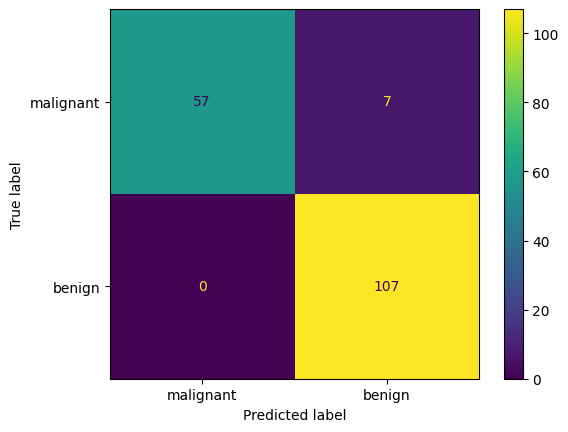

In [19]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=data.target_names)
cm_display.plot()
plt.show()

In [22]:
cr = classification_report(y_test, y_pred_knn, target_names=data.target_names, output_dict=True)
print(cr)

{np.str_('malignant'): {'precision': 1.0, 'recall': 0.890625, 'f1-score': 0.9421487603305785, 'support': 64.0}, np.str_('benign'): {'precision': 0.9385964912280702, 'recall': 1.0, 'f1-score': 0.9683257918552036, 'support': 107.0}, 'accuracy': 0.9590643274853801, 'macro avg': {'precision': 0.9692982456140351, 'recall': 0.9453125, 'f1-score': 0.9552372760928911, 'support': 171.0}, 'weighted avg': {'precision': 0.9615779214117164, 'recall': 0.9590643274853801, 'f1-score': 0.9585285402904317, 'support': 171.0}}


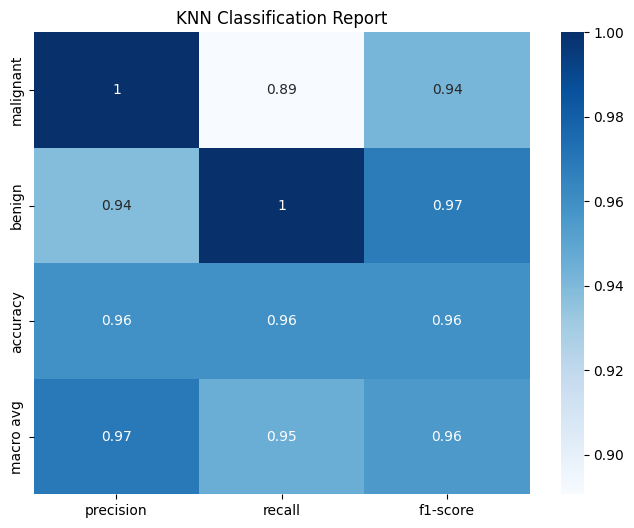

In [21]:
# classification report as a heat map
cr = classification_report(y_test, y_pred_knn, target_names=data.target_names, output_dict=True)
report_df = pd.DataFrame(cr).transpose()
plt.figure(figsize=(8,6))
sns.heatmap(report_df.iloc[:-1,:-1], annot=True, cmap="Blues")  # exclude support column for better visualization
plt.title("KNN Classification Report")
plt.show()

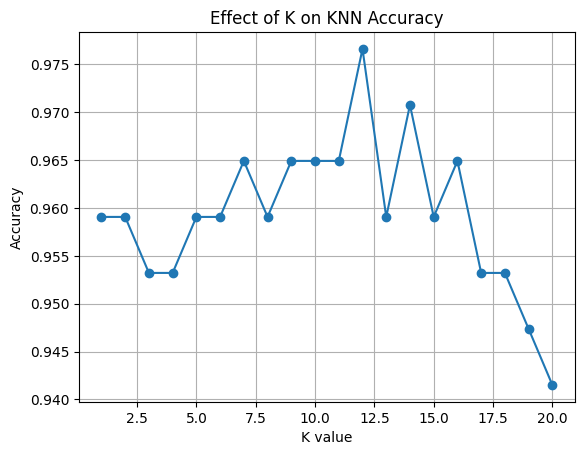

In [23]:
# Effect of k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Effect of K on KNN Accuracy")
plt.grid(True)
plt.show()

#### Naive Bayes

In [24]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb, precision_nb, recall_nb, cm_nb = classification_metrics(y_test, y_pred_nb)
acc_nb, precision_nb, recall_nb

(94.74, 93.75, 98.13)

In [25]:
# understanding NB outputs
probs = nb.predict_proba([X_test[0]])
print("Probabilities for first test sample:", probs)
print("Predicted class:", nb.predict([X_test[0]])[0])

Probabilities for first test sample: [[1.00000000e+00 3.21035602e-18]]
Predicted class: 0


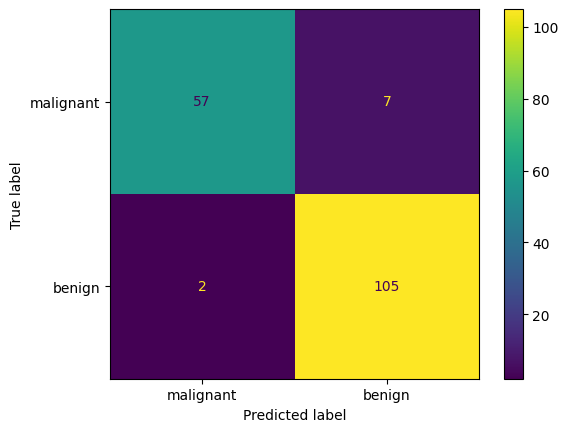

In [26]:
cm_display_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=data.target_names)
cm_display_nb.plot()
plt.show()

In [27]:
cr_nb = classification_report(y_test, y_pred_nb, target_names=data.target_names)
print(cr_nb)

              precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



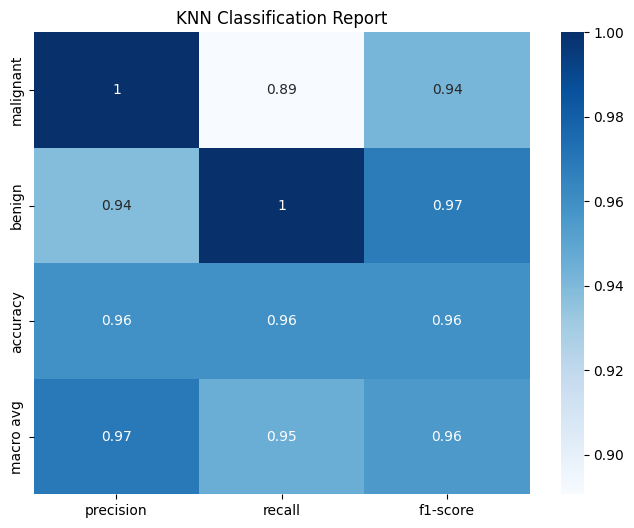

In [28]:
# classification report as a heat map
cr = classification_report(y_test, y_pred_knn, target_names=data.target_names, output_dict=True)
report_df = pd.DataFrame(cr).transpose()
plt.figure(figsize=(8,6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues")  # exclude support column for better visualization
plt.title("KNN Classification Report")
plt.show()

**Exercise**
1. Train the KNN classifier with Euclidean, Manhattan, and Chebyshev metrics. Compare accuracy, precision, and recall in a dataframe.
2. Train the KNN classifier without scaling the features and evaluate its performance using accuracy, precision, recall, and a confusion matrix. Give a detailed comparison of the results.
3. Use k-fold cross-validation to determine the optimal number of neighbors for the KNN classifier. Evaluate the KNN model with values of k ranging from 1 to 30. For each value of k, compute the average cross-validation accuracy using 5-fold cross-validation. Plot k vs. mean cross-validation accuracy. Hint: Use `cross_val_score`.
4. Identify the optimal value of k based on the highest cross-validation accuracy. Train a final KNN model using this optimal k and report its performance on the test set. Hint: Use cross_val_score.

In [34]:
#KNN with Euclidean, Manhattan, Chebyshev metrics

metrics = ["euclidean", "manhattan", "chebyshev"]

results = []

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    results.append([metric, acc, precision, recall])

df_results = pd.DataFrame(results, columns=["Metric", "Accuracy", "Precision", "Recall"])
df_results

,Metric,Accuracy,Precision,Recall
0,euclidean,0.959064,0.961578,0.959064
1,manhattan,0.953216,0.953701,0.953216
2,chebyshev,0.941520,0.941520,0.941520


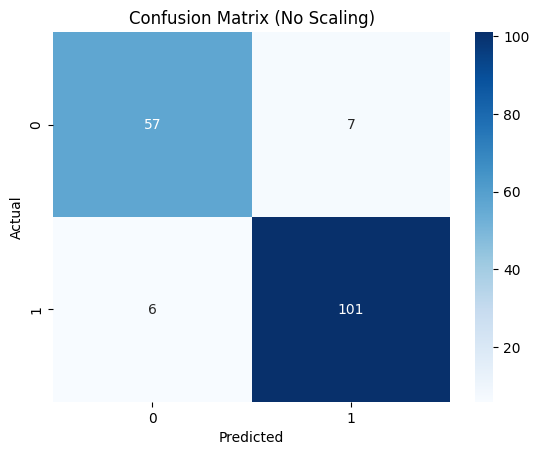

In [43]:
#KNN with features that are not scaled

knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)

y_pred_no_scale = knn_no_scale.predict(X_test)

acc_ns = accuracy_score(y_test, y_pred_no_scale)
precision_ns = precision_score(y_test, y_pred_no_scale, average='weighted')
recall_ns = recall_score(y_test, y_pred_no_scale, average='weighted')
cm_ns = confusion_matrix(y_test, y_pred_no_scale)

acc_ns, precision_ns, recall_ns

sns.heatmap(cm_ns, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (No Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


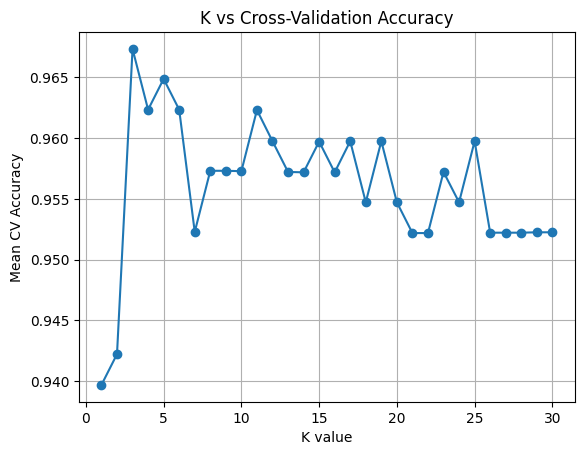

In [42]:
#Using k-fold cross-validation to determine optimal number of k neaighbors

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())

#Plot for comparison of k values as they increase
plt.plot(k_values, cv_scores, marker='o')
plt.grid(True)
plt.xlabel("K value")
plt.ylabel("Mean CV Accuracy")
plt.title("K vs Cross-Validation Accuracy")
plt.show()

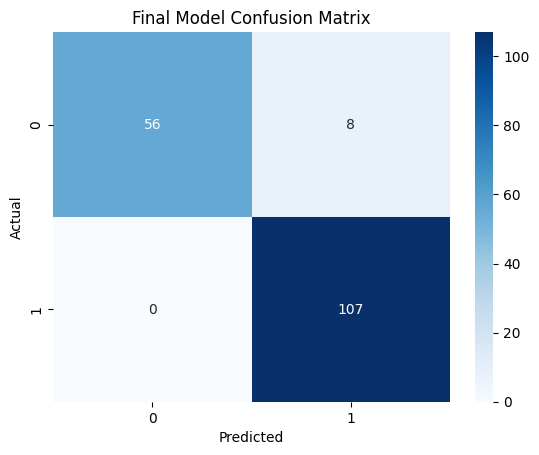

In [45]:
#Using optimal k to train final model

optimal_k = k_values[np.argmax(cv_scores)]
optimal_k

final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)

y_pred_final = final_knn.predict(X_test_scaled)

final_acc = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, average='weighted')
final_recall = recall_score(y_test, y_pred_final, average='weighted')

final_acc, final_precision, final_recall

cm_final = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()